# Práctica Guiada: Preparación de Datos y Exploración (Dataset de Crédito)

¡Bienvenido/a a la plantilla **Plug and Play**! Este notebook está listo para ejecutarse celda por celda.
Aprenderás y pondrás en práctica los cuatro pilares fundamentales del preprocesamiento de datos:
1. **Gestión de Duplicados**
2. **Tratamiento de Valores Faltantes (Missing Values)**
3. **Estandarización de Variables** (`StandardScaler`)
4. **Detección de Outliers y Exploración Visual**


## Módulo 1: Importación y Carga de Datos

En esta sección importamos las librerías científicas de Python (`pandas`, `numpy`, `matplotlib`, `seaborn`) y cargamos nuestro conjunto de datos.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
# 1. Importar librerías principales
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética para gráficos
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

# 2. Cargar el dataset

import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Clases Diplomado/películas.csv")


# 3. Vista previa general de la estructura
display(df.head(5))
print(f"Dimensiones originales: {data.shape[0]} filas y {data.shape[1]} columnas.")

,id,title,vote_average,vote_count,release_date,revenue,runtime,adult,budget
0,1097774,Aimé,0.0,0,2022-10-02,0,0,False,0
1,1005739,We're Here to Try,0.0,0,2022-08-31,0,88,False,0
2,1624666,Le Moment sera le Bon,10.0,1,2026-01-28,0,0,False,0
3,975740,Twink Temptations 11,0.0,0,2022-05-14,0,0,True,0
4,724972,In the Air Tonight,3.5,2,2020-11-03,0,11,False,0


Dimensiones originales: 200000 filas y 9 columnas.


## Módulo 2: Detección y Limpieza de Duplicados

Los registros repetidos pueden sesgar los modelos de Machine Learning. Verificaremos cuántos existen y los depuraremos.

In [6]:
# Identificar filas duplicadas
duplicados = df[df.duplicated()]
print(f"Cantidad de filas duplicadas encontradas: {len(duplicados)}")

# Eliminar duplicados de manera permanente
df.drop_duplicates(inplace=True)
print(f"Dimensiones después de eliminar duplicados: {df.shape}")

Cantidad de filas duplicadas encontradas: 42
Dimensiones después de eliminar duplicados: (199958, 9)


## Módulo 3: Tratamiento de Valores Faltantes (Missing Values)

En la vida real, los datos suelen venir incompletos. Vamos a simular nulos temporalmente para aprender a gestionarlos usando dos enfoques:
- **Eliminación (`dropna`)**
- **Imputación/Sustitución (`fillna`)**

In [7]:
# Creamos una copia para experimentar con nulos educativos
df_missing = df.copy()

np.random.seed(42)
df_missing.iloc[::4, 2] = np.nan  # Introducimos nulos en 'cuota'
df_missing.iloc[::6, 5] = np.nan  # Introducimos nulos en 'PDI'

# 1. Inspeccionar valores faltantes por columna
print("Conteo de valores nulos (NaN) introducidos:")
print(df_missing.isna().sum())

Conteo de valores nulos (NaN) introducidos:
id                  0
title               1
vote_average    49990
vote_count          0
release_date        0
revenue         33327
runtime             0
adult               0
budget              0
dtype: int64


In [8]:
# 2. Opción A: Eliminar filas con nulos (útil si hay pocos faltantes)
df_clean_dropna = df_missing.dropna()
print(f"Filas tras dropna(): {len(df_clean_dropna)}")

Filas tras dropna(): 133305


In [10]:
# 3. Opción B: Rellenar nulos (Imputación por la media o valor constante)
df_clean_fillna = df_missing.copy()
df_clean_fillna['vote_average'] = df_clean_fillna['vote_average'].fillna(df_clean_fillna['vote_average'].mean())
df_clean_fillna['revenue'] = df_clean_fillna['revenue'].fillna(df_clean_fillna['revenue'].median())

print("\nNulos después de aplicar fillna():")
print(df_clean_fillna.isna().sum())


Nulos después de aplicar fillna():
id              0
title           1
vote_average    0
vote_count      0
release_date    0
revenue         0
runtime         0
adult           0
budget          0
dtype: int64


## Módulo 4: Estandarización de Datos (`StandardScaler`)

Estandarizar transforma las variables para que tengan **media = 0** y **desviación estándar = 1**, evitando que variables con escalas grandes dominen sobre las demás.

In [12]:
from sklearn.preprocessing import StandardScaler

# Seleccionamos únicamente las columnas numéricas de los datos limpios para escalar
df_numerico = df.dropna().select_dtypes(include=['float64', 'int64'])

# Aplicar StandardScaler
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_numerico)
df_scaled = pd.DataFrame(scaled_array, columns=df_numerico.columns)

In [13]:
# Comprobación matemática
print("Medias tras escalar (deben ser prácticamente 0):")
print(df_scaled.mean().round(4))

print("\nDesviaciones estándar tras escalar (deben ser 1):")
print(df_scaled.std().round(4))

Medias tras escalar (deben ser prácticamente 0):
id              0.0
vote_average   -0.0
vote_count     -0.0
revenue        -0.0
runtime         0.0
budget         -0.0
dtype: float64

Desviaciones estándar tras escalar (deben ser 1):
id              1.0
vote_average    1.0
vote_count      1.0
revenue         1.0
runtime         1.0
budget          1.0
dtype: float64


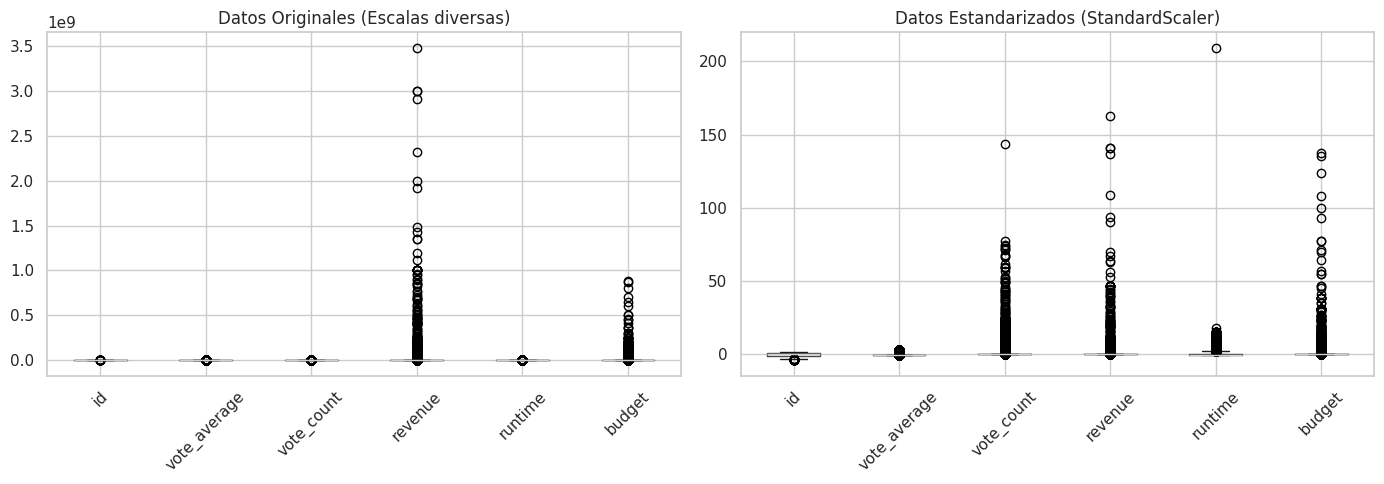

In [14]:
# Visualizar impacto con Boxplots
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_numerico.boxplot(ax=axes[0])
axes[0].set_title('Datos Originales (Escalas diversas)')
axes[0].tick_params(axis='x', rotation=45)

df_scaled.boxplot(ax=axes[1])
axes[1].set_title('Datos Estandarizados (StandardScaler)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Módulo 5: Detección y Tratamiento de Outliers

Analizaremos los valores atípicos mediante gráficos estadísticos y reglas de filtrado basadas en la desviación estándar.

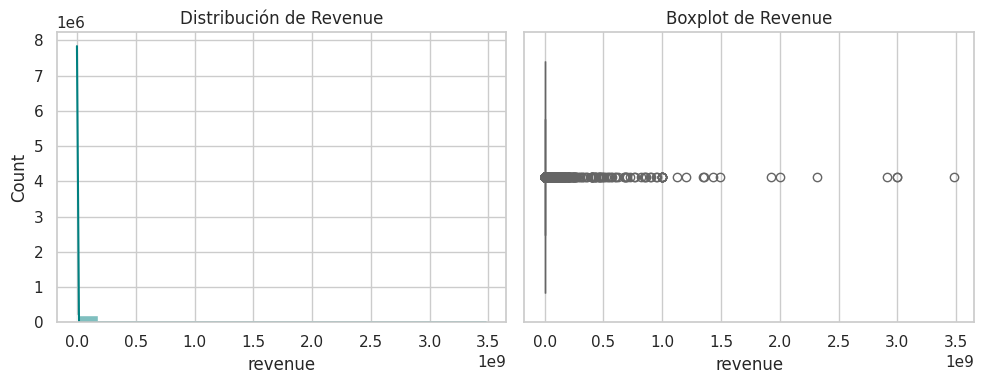

In [16]:
# Analizar la variable 'revenue'
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_numerico['revenue'], kde=True, color='teal')
plt.title('Distribución de Revenue')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_numerico['revenue'], color='coral')
plt.title('Boxplot de Revenue')
plt.tight_layout()
plt.show()

In [18]:
# Filtrado de outliers usando el criterio de 3 desviaciones estándar (Z-Score)
import numpy as np

columna_obj = 'revenue'
media = df_numerico[columna_obj].mean()
desv = df_numerico[columna_obj].std()

df_sin_outliers = df_numerico[
    np.abs(df_numerico[columna_obj] - media) <= 3 * desv
]
print(f"Registros originales: {len(df_numerico)} | Tras filtrar outliers: {len(df_sin_outliers)}")

Registros originales: 199957 | Tras filtrar outliers: 199767


## Módulo 6: Exploración Analítica (Univariada y Bivariada)

Finalizamos resumiendo métricas estadísticas y segmentando la información según el perfil de riesgo crediticio.

Resumen estadístico de las variables numéricas:


,id,vote_average,vote_count,revenue,runtime,budget
count,1.999570e+05,199957.000000,199957.000000,1.999570e+05,199957.000000,1.999570e+05
mean,1.165874e+06,1.272811,6.099381,4.341134e+05,40.588296,1.888620e+05
std,2.822528e+05,2.849071,127.057809,2.132677e+07,63.466358,6.452903e+06
min,3.089400e+04,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
25%,9.353470e+05,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
50%,1.157722e+06,0.000000,0.000000,0.000000e+00,13.000000,0.000000e+00
75%,1.414242e+06,0.000000,0.000000,0.000000e+00,78.000000,0.000000e+00
max,1.655819e+06,10.000000,18299.000000,3.477780e+09,13319.000000,8.880000e+08


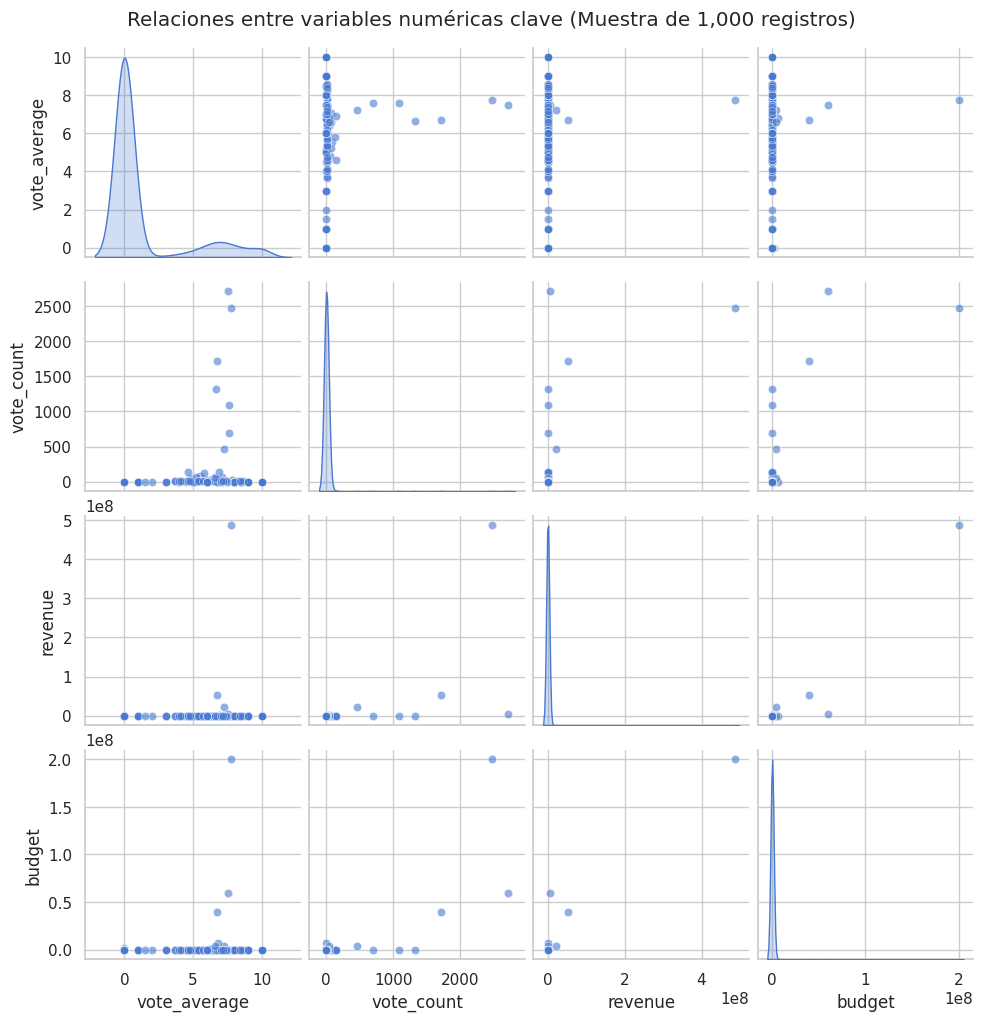

In [20]:
# 1. Estadísticas descriptivas generales
print("Resumen estadístico de las variables numéricas:")
display(df_numerico.describe())

# 2. Relación bivariada visual rápida usando variables clave del dataset de películas
variables_clave = ['vote_average', 'vote_count', 'revenue', 'budget']

# Creamos un pairplot rápido para analizar correlaciones y distribuciones cruzadas
sns.pairplot(df_numerico[variables_clave].sample(n=1000, random_state=42), diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Relaciones entre variables numéricas clave (Muestra de 1,000 registros)', y=1.02)
plt.show()